In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


In [2]:
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

data_file = REPO_ROOT / "data" / "aqmola" / "Akmola_S1_patchmean_20m_10d_20250101_20251231.csv"
eu_data_file = REPO_ROOT / "data" / "prepared" / "S1_point_all_10d_10m_20180101-20180731_Stratum1_VV-VH.csv"
target_crop = "пшеница"
target_crop_label = "Wheat"
common_wheat_level2 = 211


In [3]:
df = pd.read_csv(data_file)
eu_df = pd.read_csv(eu_data_file, dtype={"level_1": int, "level_2": int})
print(f"Loaded Akmola dataset with shape {df.shape}")
print(f"Loaded EU reference dataset with shape {eu_df.shape}")

wheat_df = df[df["crop"] == target_crop].copy()
common_wheat_df = eu_df[eu_df["level_2"] == common_wheat_level2].copy()
print(f"Rows for '{target_crop}': {len(wheat_df)}")
print(f"Rows for common wheat (level_2={common_wheat_level2}): {len(common_wheat_df)}")

if wheat_df.empty:
    raise ValueError(f"No rows found for crop '{target_crop}' in {data_file.name}")

if common_wheat_df.empty:
    raise ValueError(f"No common wheat rows found in {eu_data_file.name}")

wheat_df.head()


Loaded Akmola dataset with shape (276, 76)
Loaded EU reference dataset with shape (1743815, 46)
Rows for 'пшеница': 205
Rows for common wheat (level_2=211): 195821


,system:index,POINT_ID,VH_20250101,VH_20250111,VH_20250121,VH_20250131,VH_20250210,VH_20250220,VH_20250302,VH_20250312,...,VV_20251008,VV_20251018,VV_20251028,VV_20251107,VV_20251117,VV_20251127,VV_20251207,VV_20251217,crop,.geo
2,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-13.070312,-14.328904,-15.417213,-14.876905,-11.502509,-14.785150,NaN,-14.367247,пшеница,"{""type"":""Polygon"",""coordinates"":[[[71.909225,5..."
3,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-18.783580,-19.748477,-19.465194,-12.851646,-11.284899,-18.415889,NaN,-15.217057,пшеница,"{""type"":""Polygon"",""coordinates"":[[[71.920071,5..."
4,4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-14.801025,-17.034267,-18.640547,-15.085056,-11.884626,-16.741954,NaN,-16.066587,пшеница,"{""type"":""Polygon"",""coordinates"":[[[71.919362,5..."
5,5,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-16.761864,-17.514159,-19.175132,-14.823964,-12.402900,-17.855137,NaN,-14.735351,пшеница,"{""type"":""Polygon"",""coordinates"":[[[71.918589,5..."
6,6,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-16.695020,-17.564202,-14.553487,-17.881173,-9.835209,-15.399455,NaN,-15.332321,пшеница,"{""type"":""Polygon"",""coordinates"":[[[72.018904,5..."


In [4]:
import re

date_pattern = re.compile(r"^(VH|VV)_(\d{8})$")

def extract_radar_columns(frame, prefix):
    cols = []
    for col in frame.columns:
        match = date_pattern.match(col)
        if match and match.group(1) == prefix:
            cols.append((match.group(2), col))
    cols.sort()
    return cols

def compute_mean_curve(frame, columns):
    if not columns:
        return pd.Series(dtype=float)
    return frame[columns].apply(pd.to_numeric, errors="coerce").mean()

kz_vh = extract_radar_columns(wheat_df, "VH")
kz_vv = extract_radar_columns(wheat_df, "VV")
eu_vh = extract_radar_columns(common_wheat_df, "VH")
eu_vv = extract_radar_columns(common_wheat_df, "VV")

if not kz_vh or not kz_vv:
    raise ValueError("No Akmola VH/VV date columns were found in the selected dataset.")

vh_dates = [date for date, _ in kz_vh]
vv_dates = [date for date, _ in kz_vv]
if vh_dates != vv_dates:
    raise ValueError("Akmola VH and VV columns do not share the same date grid.")

vh_columns = [col for _, col in kz_vh]
vv_columns = [col for _, col in kz_vv]
vh_mean = compute_mean_curve(wheat_df, vh_columns)
vv_mean = compute_mean_curve(wheat_df, vv_columns)

eu_vh_by_mmdd = {date[4:]: col for date, col in eu_vh}
eu_vv_by_mmdd = {date[4:]: col for date, col in eu_vv}
eu_vh_columns = [eu_vh_by_mmdd.get(date[4:]) for date in vh_dates]
eu_vv_columns = [eu_vv_by_mmdd.get(date[4:]) for date in vv_dates]

eu_vh_mean = pd.Series([common_wheat_df[col].astype(float).mean() if col else float("nan") for col in eu_vh_columns])
eu_vv_mean = pd.Series([common_wheat_df[col].astype(float).mean() if col else float("nan") for col in eu_vv_columns])

plot_labels = [f"{label[4:6]}-{label[6:8]}" for label in vh_dates]
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
tick_count = min(12, len(vh_dates))
tick_positions = [round(i * (len(vh_dates) - 1) / (tick_count - 1)) for i in range(tick_count)] if tick_count > 1 else [0]
tick_labels = [f"{month_names[int(vh_dates[i][4:6]) - 1]} {int(vh_dates[i][6:8])}" for i in tick_positions]

mean_curves = pd.DataFrame({
    "date": plot_labels,
    "Akmola_VH_mean": vh_mean.values,
    "EU_common_wheat_VH_mean": eu_vh_mean.values,
    "Akmola_VV_mean": vv_mean.values,
    "EU_common_wheat_VV_mean": eu_vv_mean.values,
})
mean_curves


,date,Akmola_VH_mean,EU_common_wheat_VH_mean,Akmola_VV_mean,EU_common_wheat_VV_mean
0,01-01,NaN,-17.638939,NaN,-8.729834
1,01-11,NaN,-19.502042,NaN,-10.294926
2,01-21,NaN,-18.389893,NaN,-9.523081
3,01-31,NaN,-19.600192,NaN,-10.342842
4,02-10,NaN,-20.454614,NaN,-11.105093
5,02-20,NaN,-22.340593,NaN,-12.682183
6,03-02,NaN,-20.368115,NaN,-11.135361
7,03-12,NaN,-20.005960,NaN,-10.321410
8,03-22,-21.261197,-19.612918,-12.789955,-10.253671
9,04-01,-22.274679,-18.679201,-12.244475,-10.210037


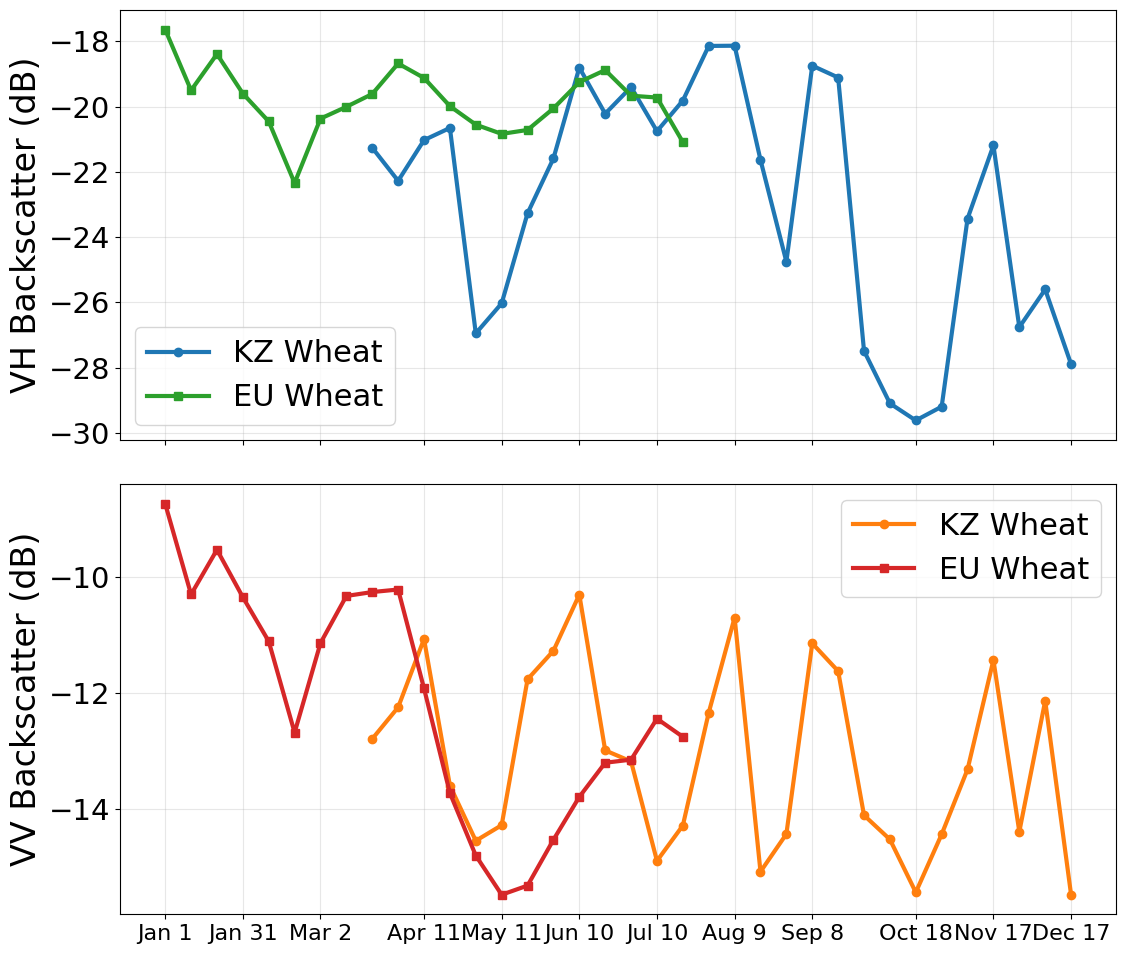

In [6]:
plt.rcParams.update({
    "font.size": 22,
    "axes.labelsize": 24,
    "xtick.labelsize": 16,
    "ytick.labelsize": 21,
    "legend.fontsize": 22,
})

x = range(len(plot_labels))
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

axes[0].plot(x, vh_mean, marker="o", linewidth=3, color="tab:blue", label=f"KZ {target_crop_label}")
axes[0].plot(x, eu_vh_mean, marker="s", linewidth=3, color="tab:green", label="EU Wheat")
axes[0].set_ylabel("VH Backscatter (dB)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(x, vv_mean, marker="o", linewidth=3, color="tab:orange", label=f"KZ {target_crop_label}")
axes[1].plot(x, eu_vv_mean, marker="s", linewidth=3, color="tab:red", label="EU Wheat")
axes[1].set_ylabel("VV Backscatter (dB)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.xticks(tick_positions, tick_labels)
plt.tight_layout()
plt.savefig('wheat.png', dpi=600)
